# MERGE: Multi-Expert Regime's Gaussian Ensemble 
## F1TENTH Autonomous Racing Simulation Pipeline

This notebook implements the complete trajectory synthesis and simulation pipeline for the MERGE algorithm. It proceeds in three main phases:
1. **Data Generation:** Simulating a heterogeneous library of expert demonstrations using a Pure Pursuit controller at varying speeds.
2. **Trajectory Synthesis:** Applying the MERGE GMM-based segmentation and Viterbi dynamic programming to stitch an optimal, kinematically feasible racing line.
3. **Closed-Loop Execution:** Tracking the synthesized trajectory using a modified, velocity-scheduled Stanley controller under noisy initial conditions.

### 1. Imports and Environment Setup
We import standard scientific libraries alongside the custom F1TENTH vehicle dynamics model and the MERGE optimal switching utilities.

In [10]:
# %matplotlib widget
import numpy as np
from os.path import join
from datetime import datetime
from functools import partial
from scipy.interpolate import splev, splrep

# Custom F1TENTH Simulator and Controller Hub
from f1tenth_gym_model.gym_car import Car
from f1tenth_gym_model.controllers import GeomtricControllersHub, simulate_controllers

# MERGE Core Utilities
from MERGE_utils.handler import SwitchingController, generate_opt_trajectory
from trajectory_utils.waypoint import WayPoint 
from trajectory_utils.plotter import plot_waypoints, plot_trajectory_data, set_publication_style
from trajectory_utils.data import traj_data_dict_get, save_traj_data, load_traj_data, print_details

# Enforce clean, paper-ready plotting aesthetics
set_publication_style()

### 2. Vehicle Dynamics Configuration
Here we define the physical constraints of the 1:10 scale autonomous race car. These parameters govern both the simulation fidelity (tyre friction, inertia) and the kinematic safety bounds used during trajectory synthesis.

In [11]:
# Single-track (Bicycle) model parameters for the F1TENTH platform
CAR_PARAMS = {
    'mu': 1.0489,        # Surface friction coefficient
    'C_Sf': 4.718,       # Front cornering stiffness
    'C_Sr': 5.4562,      # Rear cornering stiffness
    'lf': 0.15875,       # Distance from CoM to front axle (m)
    'lr': 0.17145,       # Distance from CoM to rear axle (m)
    'h': 0.074,          # Height of CoM (m)
    'm': 3.74,           # Vehicle mass (kg)
    'width': 0.31,       # Chassis width (m)
    'length': 0.58,      # Chassis length (m)
    'I': 0.04712,        # Yaw moment of inertia (kg*m^2)
    's_min': -0.4189,    # Min steering angle (approx -24 deg)
    's_max': 0.4189,     # Max steering angle (approx +24 deg)
    'sv_min': -3.2,      # Min steering velocity (rad/s)
    'sv_max': 3.2,       # Max steering velocity (rad/s)
    'v_switch': 7.319,   # Velocity threshold for kinematic to dynamic model switch
    'a_max': 9.51,       # Maximum longitudinal acceleration limit (m/s^2)
    'v_min': -5.0,       # Minimum velocity (m/s)
    'v_max': 20.0,       # Maximum velocity limit (m/s)
    'g': 9.81,           # Gravity
    'dt': 1e-2,          # Simulation timestep (100 Hz)
    'X0': np.zeros(7),   # Initial state vector placeholder
}

### 3. Track Loading and Spatial Parameterization
We load the reference centerline for the desired racing circuit. The `WayPoint` object handles the transformation from global Cartesian coordinates to the progress-parameterized Frenet frame ($s$), which is essential for decoupling spatial geometry from velocity.

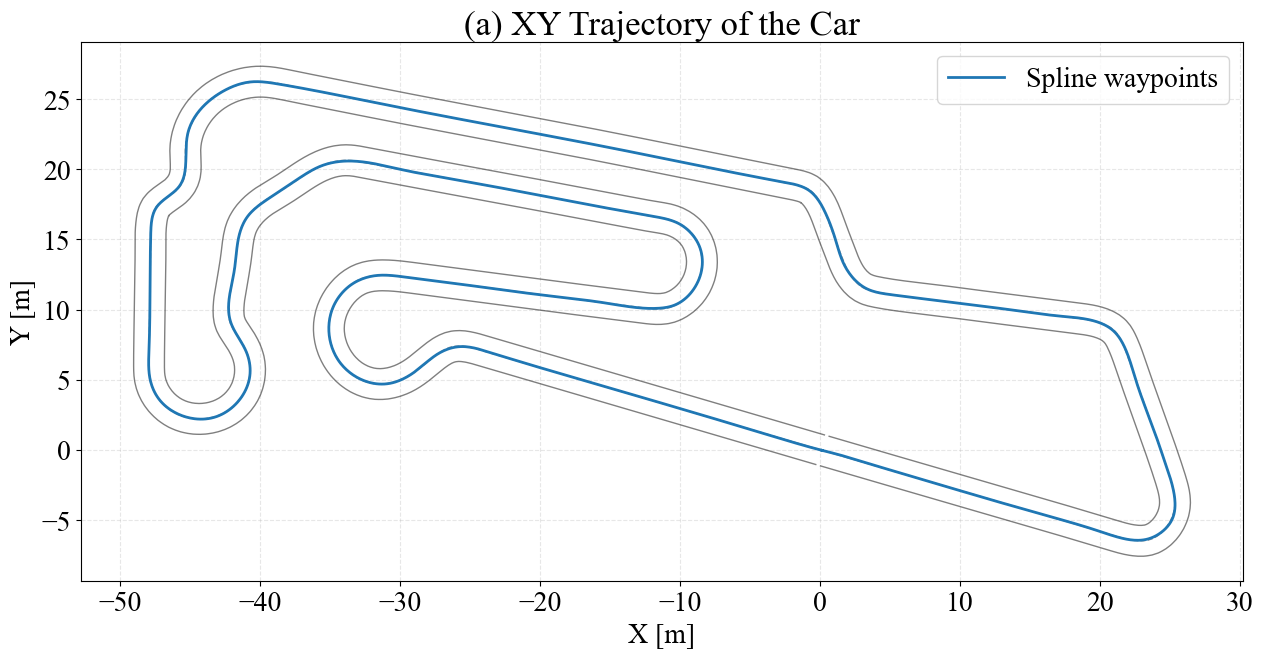

In [12]:
FILEDATE = datetime.now().strftime("%Y-%m-%d_%H-%M")

# Select the target track for synthesis and evaluation
RACE_TRACK_PATH = join("f1tenth_racetracks", "Oschersleben", "Oschersleben_centerline.csv")

# Parse the centerline and generate smoothed spline representations
WP = WayPoint(
    path_to_waypts=RACE_TRACK_PATH, 
    waypoint_density=10.,     # Interpolation density
    waypoints_width=2.2,      # Total drivable track width (m)
    smoothness_params=np.full(2, 1.), # Spline smoothing factors
)

### 4. Expert Demonstration Generation
To synthesize an optimal trajectory, MERGE requires a heterogeneous library of suboptimal experts. We generate this dataset by simulating the car using a basic Pure Pursuit controller, incrementing the target velocity from a conservative 6.0 m/s up to an aggressive 12.0 m/s. 

*Note: Faster experts will naturally deviate further from the centerline in corners, providing the behavioral variance needed for GMM segmentation.*

In [13]:
# Align the car's initial position and heading with the track start line
CAR_PARAMS["X0"][:2] = WP.waypoints[0]
CAR_PARAMS["X0"][4] = np.arctan2(*((WP.waypoints[1]-WP.waypoints[0])[::-1]))
C = Car(**CAR_PARAMS)

# Initialize the controller hub for generating the pure pursuit demonstrations
GCH = GeomtricControllersHub(
    car_dt=C.dt,
    car_lf=C.lf,
    car_lr=C.lr,
    vel_thresh=1e-2,
    look_ahead_progress=1./WP.cumulative_dists[-1], # Normalized lookahead base
)


TDList_Demo = []

# Generate 13 experts ranging from conservative to aggressive
for count, vel in enumerate(np.linspace(6., 12., 13)):
    print(f"\n--------------- DEMO {count + 1} --------------\n")
    print(f"[INFO]: Speed States -> Desired = {round(vel, 4)}")

    # Scale the spatial lookahead distance based on target velocity
    GCH.look_ahead_progress = vel * 1e-3
    CAR_PARAMS["X0"][3] = vel
    
    # Reset car to start line using the dynamic model flag
    C.reset(X0=CAR_PARAMS["X0"], kinematic_flag=False)

    # Rollout the simulation for the current expert
    TDList_Demo.append(simulate_controllers(
        C=C,
        progress_func=WP.find_progress_value,
        # Compute dynamic reference points using splined track evaluation
        desired_xy_func=lambda progress: np.array([splev(progress + GCH.look_ahead_progress, tck) for tck in WP.waypoints_tck[:2]]),
        desired_phi_func=lambda progress: np.arctan2(*[splev(progress, tck) for tck in WP.waypoints_dot_tck[:2][::-1]]),
        velocity_ctrl_func=lambda progress: vel,
        steering_ctrl_fun=GCH.pure_pursuit_ctrl,
        completion_thresh=0.1/WP.cumulative_dists[-1],
        simulation_duration=75.,
    ))

    # Calculate lateral Frenet deviation (e) for the variance analysis
    TDList_Demo[-1]["deviations"] = WP.compute_deviations(TDList_Demo[-1]["states"][:, :2])
    print_details([TDList_Demo[-1]])
    
print("\n")

# Save the raw expert library for offline analysis
TRAJ_DATA_PATH = join("data_dummy", f"TDList_Demo_{FILEDATE}.pkl")
save_traj_data(TDList_Demo, TRAJ_DATA_PATH)


--------------- DEMO 1 --------------

[INFO]: Speed States -> Desired = 6.0
[INFO]: Lap Time Stats -> Min = 43.71 s
[INFO]: Lap Time Stats -> Mean = 43.71 s
[INFO]: Lap Time Stats -> Max = 43.71 s
[INFO]: Speed Stats -> Min = 6.0 m/s
[INFO]: Speed Stats -> Mean = 6.0 m/s
[INFO]: Speed Stats -> Max = 6.0 m/s
[INFO]: Deviation Stats -> Min = 0.0 m
[INFO]: Deviation Stats -> Mean = 0.0589 m
[INFO]: Deviation Stats -> Max = 0.3111 m

--------------- DEMO 2 --------------

[INFO]: Speed States -> Desired = 6.5
[INFO]: Lap Time Stats -> Min = 40.43 s
[INFO]: Lap Time Stats -> Mean = 40.43 s
[INFO]: Lap Time Stats -> Max = 40.43 s
[INFO]: Speed Stats -> Min = 6.5 m/s
[INFO]: Speed Stats -> Mean = 6.5 m/s
[INFO]: Speed Stats -> Max = 6.5 m/s
[INFO]: Deviation Stats -> Min = 0.0 m
[INFO]: Deviation Stats -> Mean = 0.0737 m
[INFO]: Deviation Stats -> Max = 0.3542 m

--------------- DEMO 3 --------------

[INFO]: Speed States -> Desired = 7.0
[INFO]: Lap Time Stats -> Min = 37.64 s
[INFO]: Lap 

### 5. Visualizing the Expert Library
Before optimization, we plot the generated demonstrations. Viewing them against normalized progress (s) clearly reveals the regions of high structural variance (corners) versus low variance (straights).

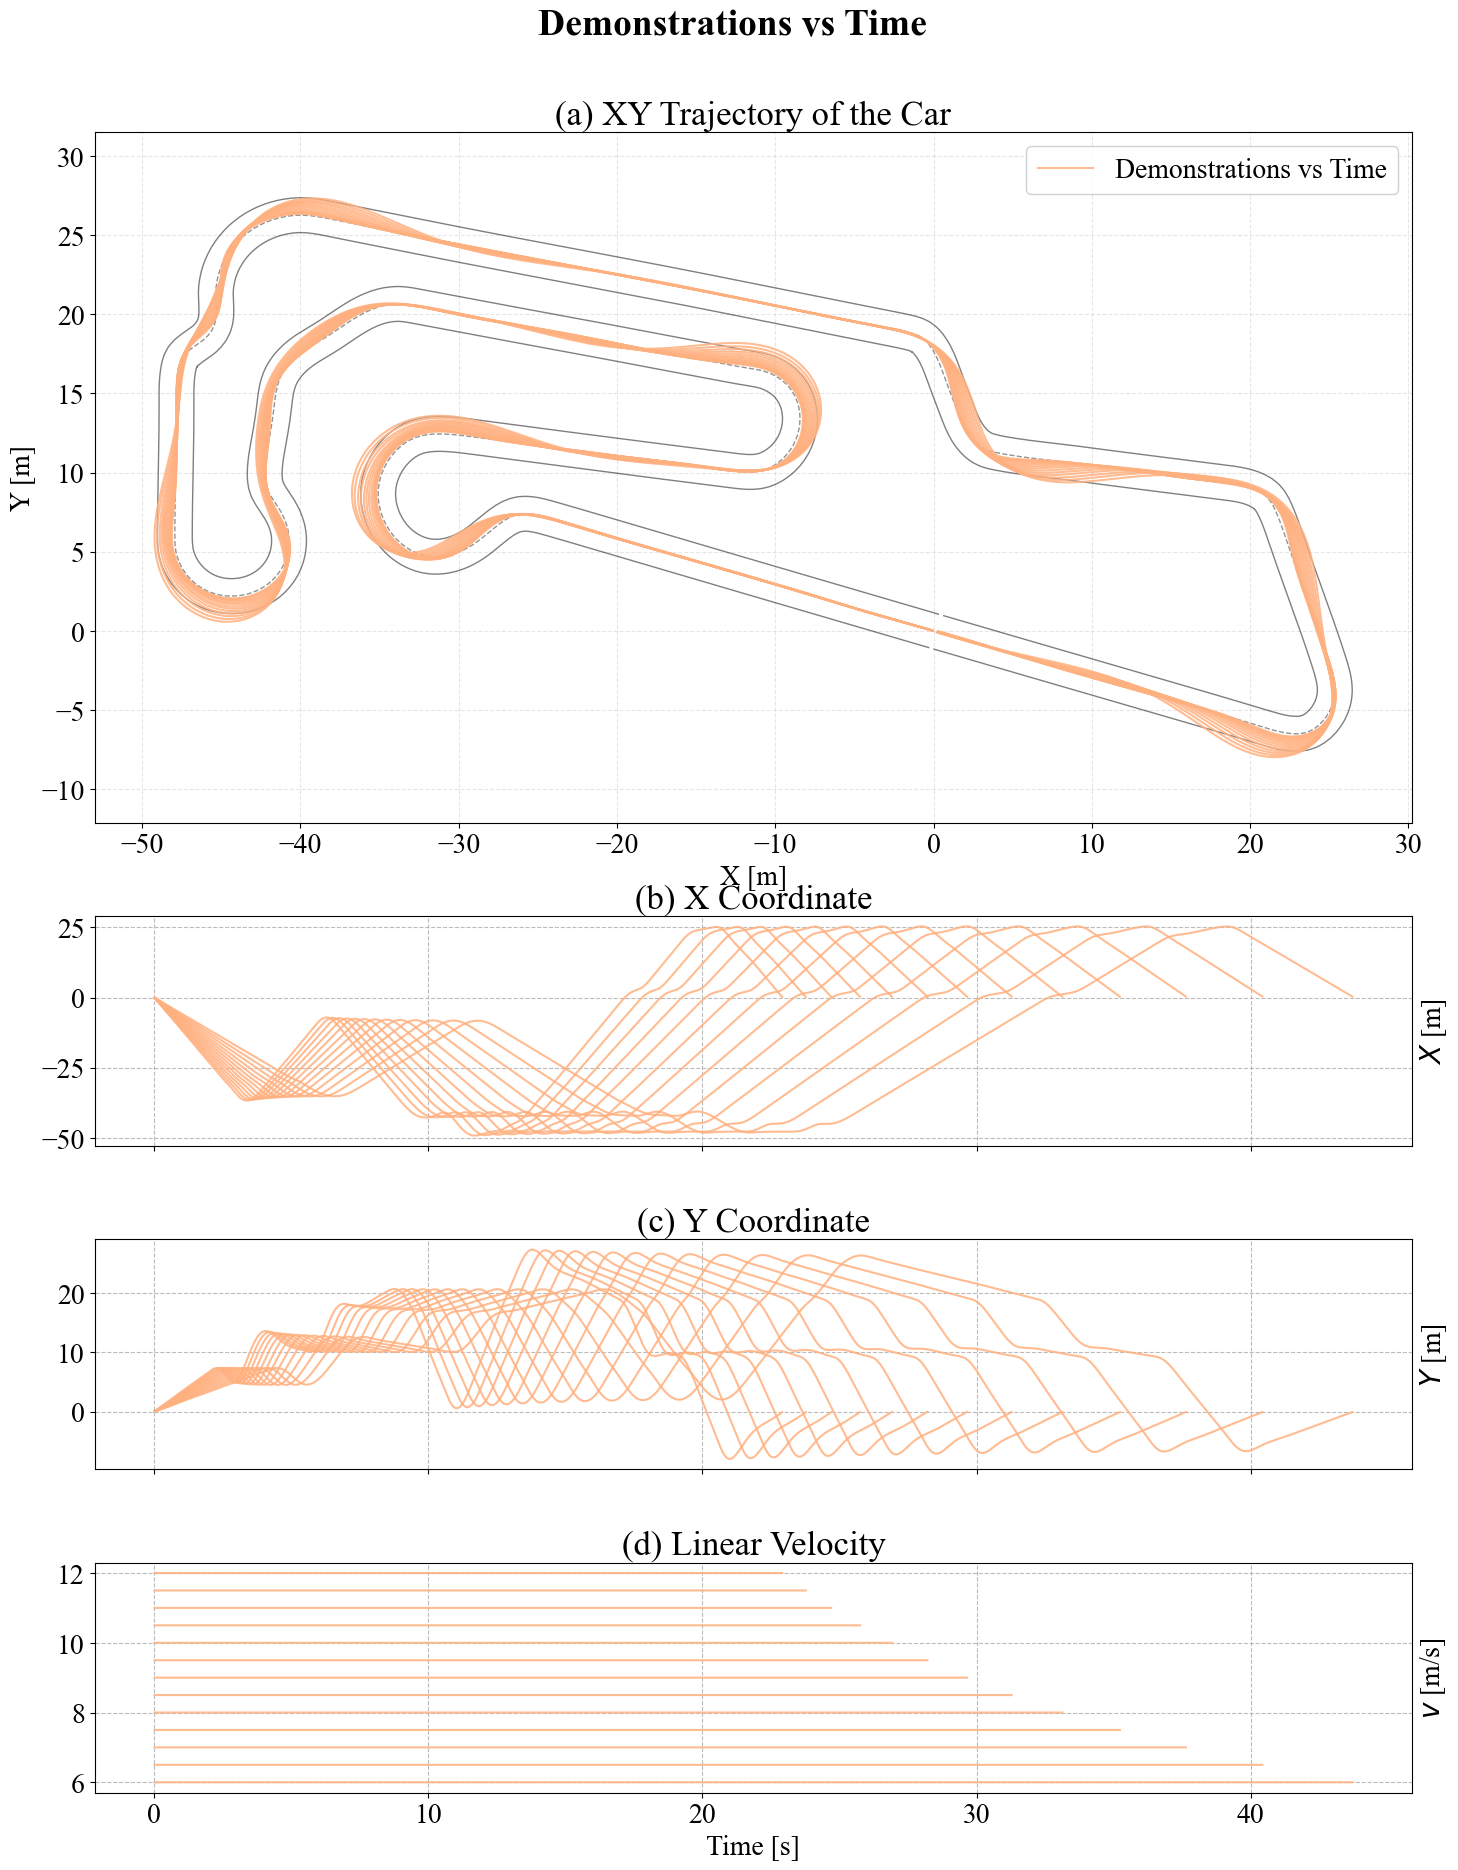

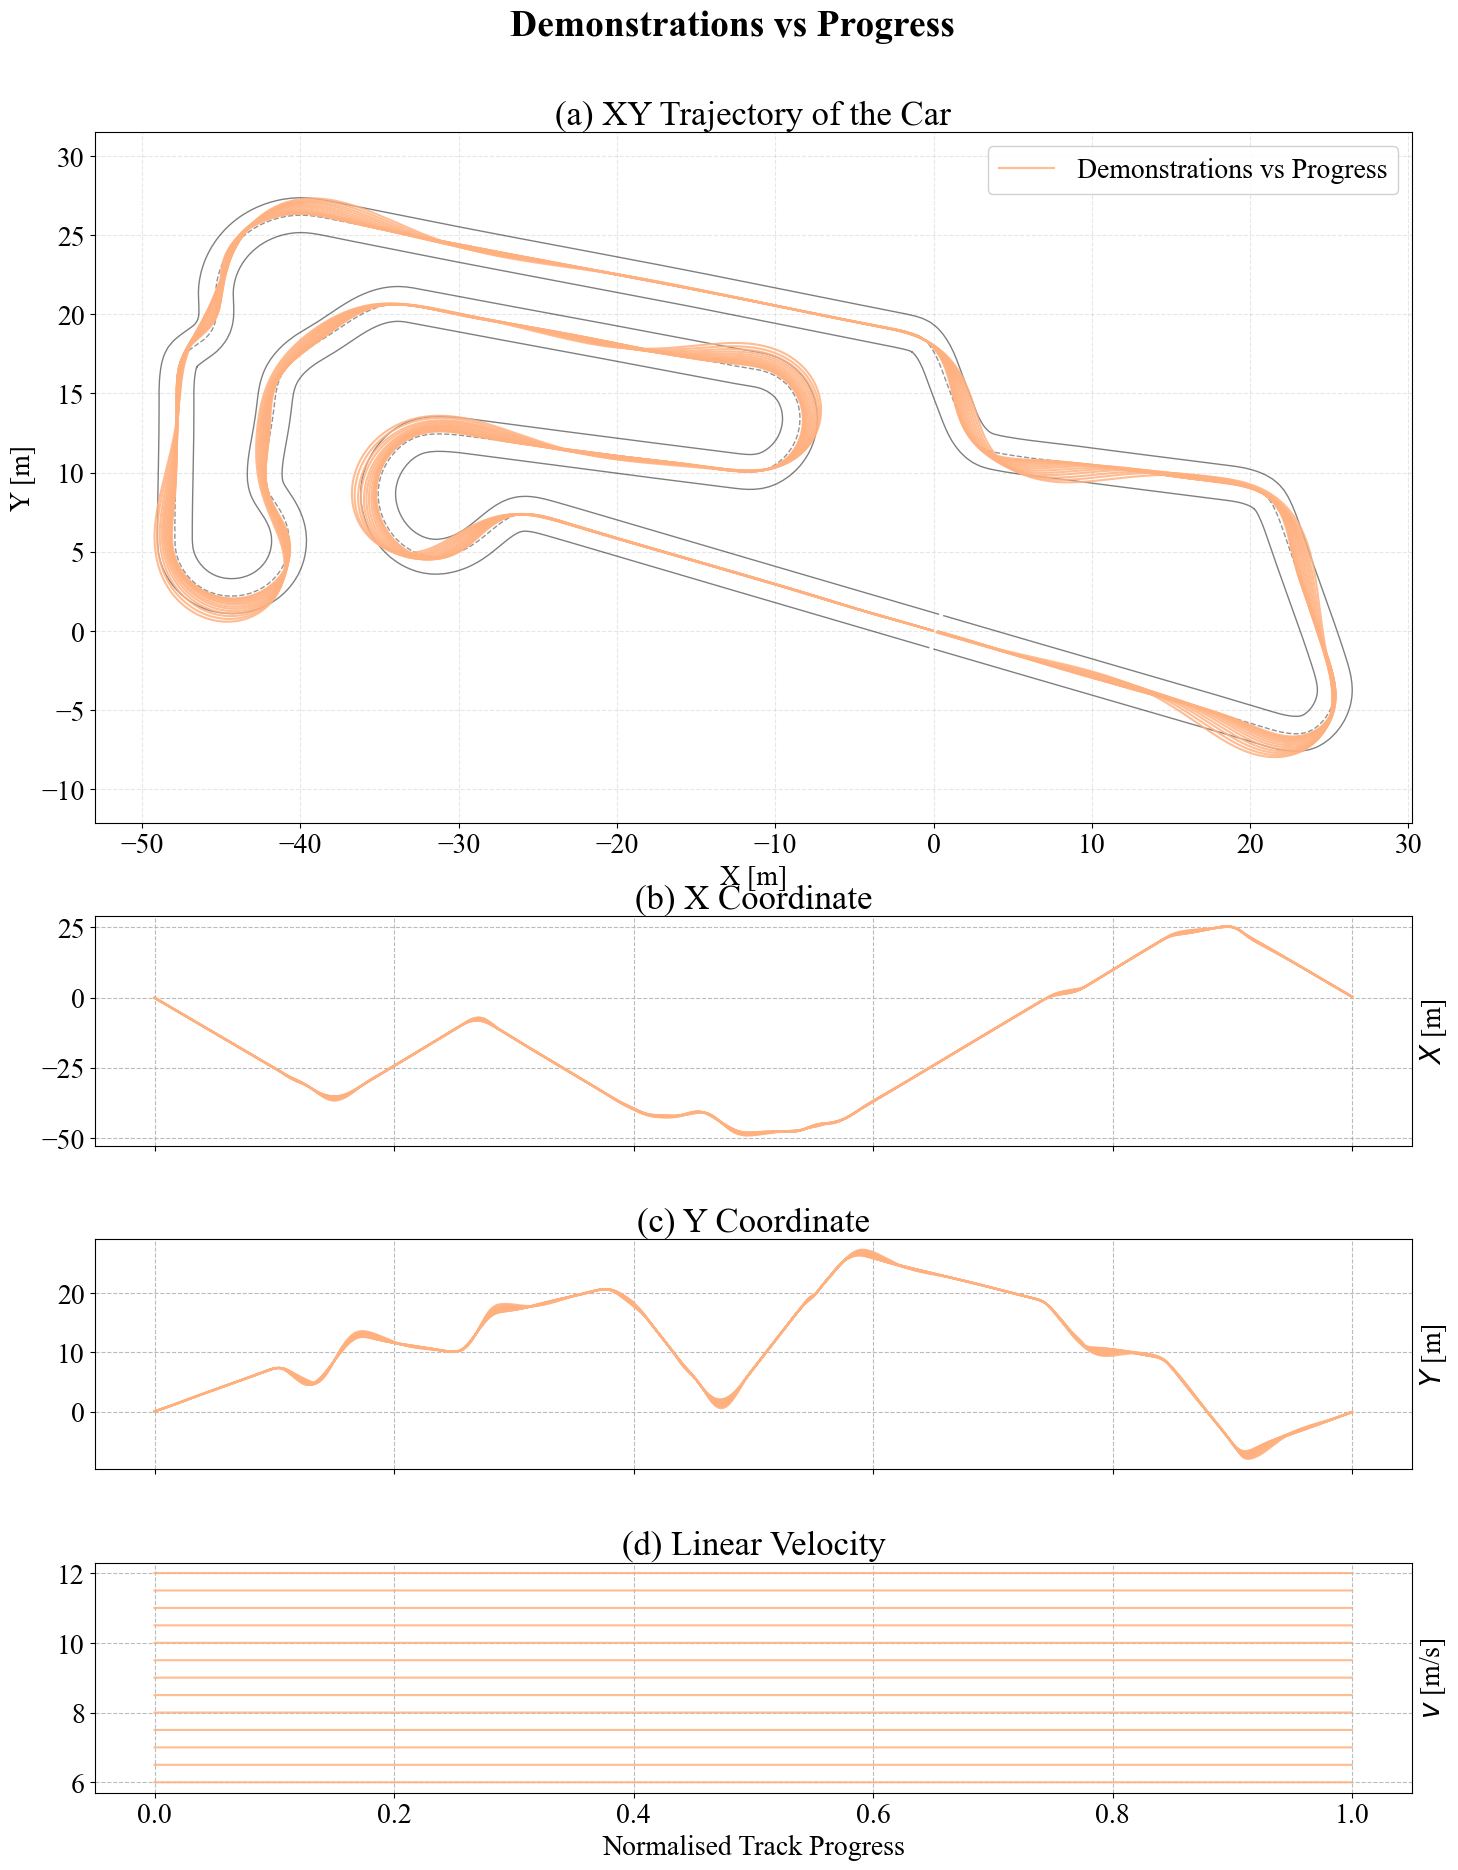

In [14]:
plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_demo=TDList_Demo, 
    plot_state_indices=[0, 1, 3],
    TD_demo_name="Demonstrations vs Time",
    TD_learnt_name="", 
    filedate=FILEDATE
)

plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations vs Progress",
    plot_state_indices=[0, 1, 3],
    TD_learnt_name="", 
    x_axis_time=False,
    filedate=FILEDATE
)

### 6. The MERGE Core Pipeline: Optimal Trajectory Synthesis
This is the heart of the algorithm. `generate_opt_trajectory` executes the following:
1. Fits a Gaussian Mixture Model to the spatial variance, discovering "Smart Bins".
2. Constructs a Viterbi Trellis, penalizing unsafe lateral deviations and unfeasible acceleration spikes during expert transitions.
3. Extracts the globally optimal sequence of experts.
4. Performs a soft $C^\infty$ convex blending using the GMM spatial responsibilities.

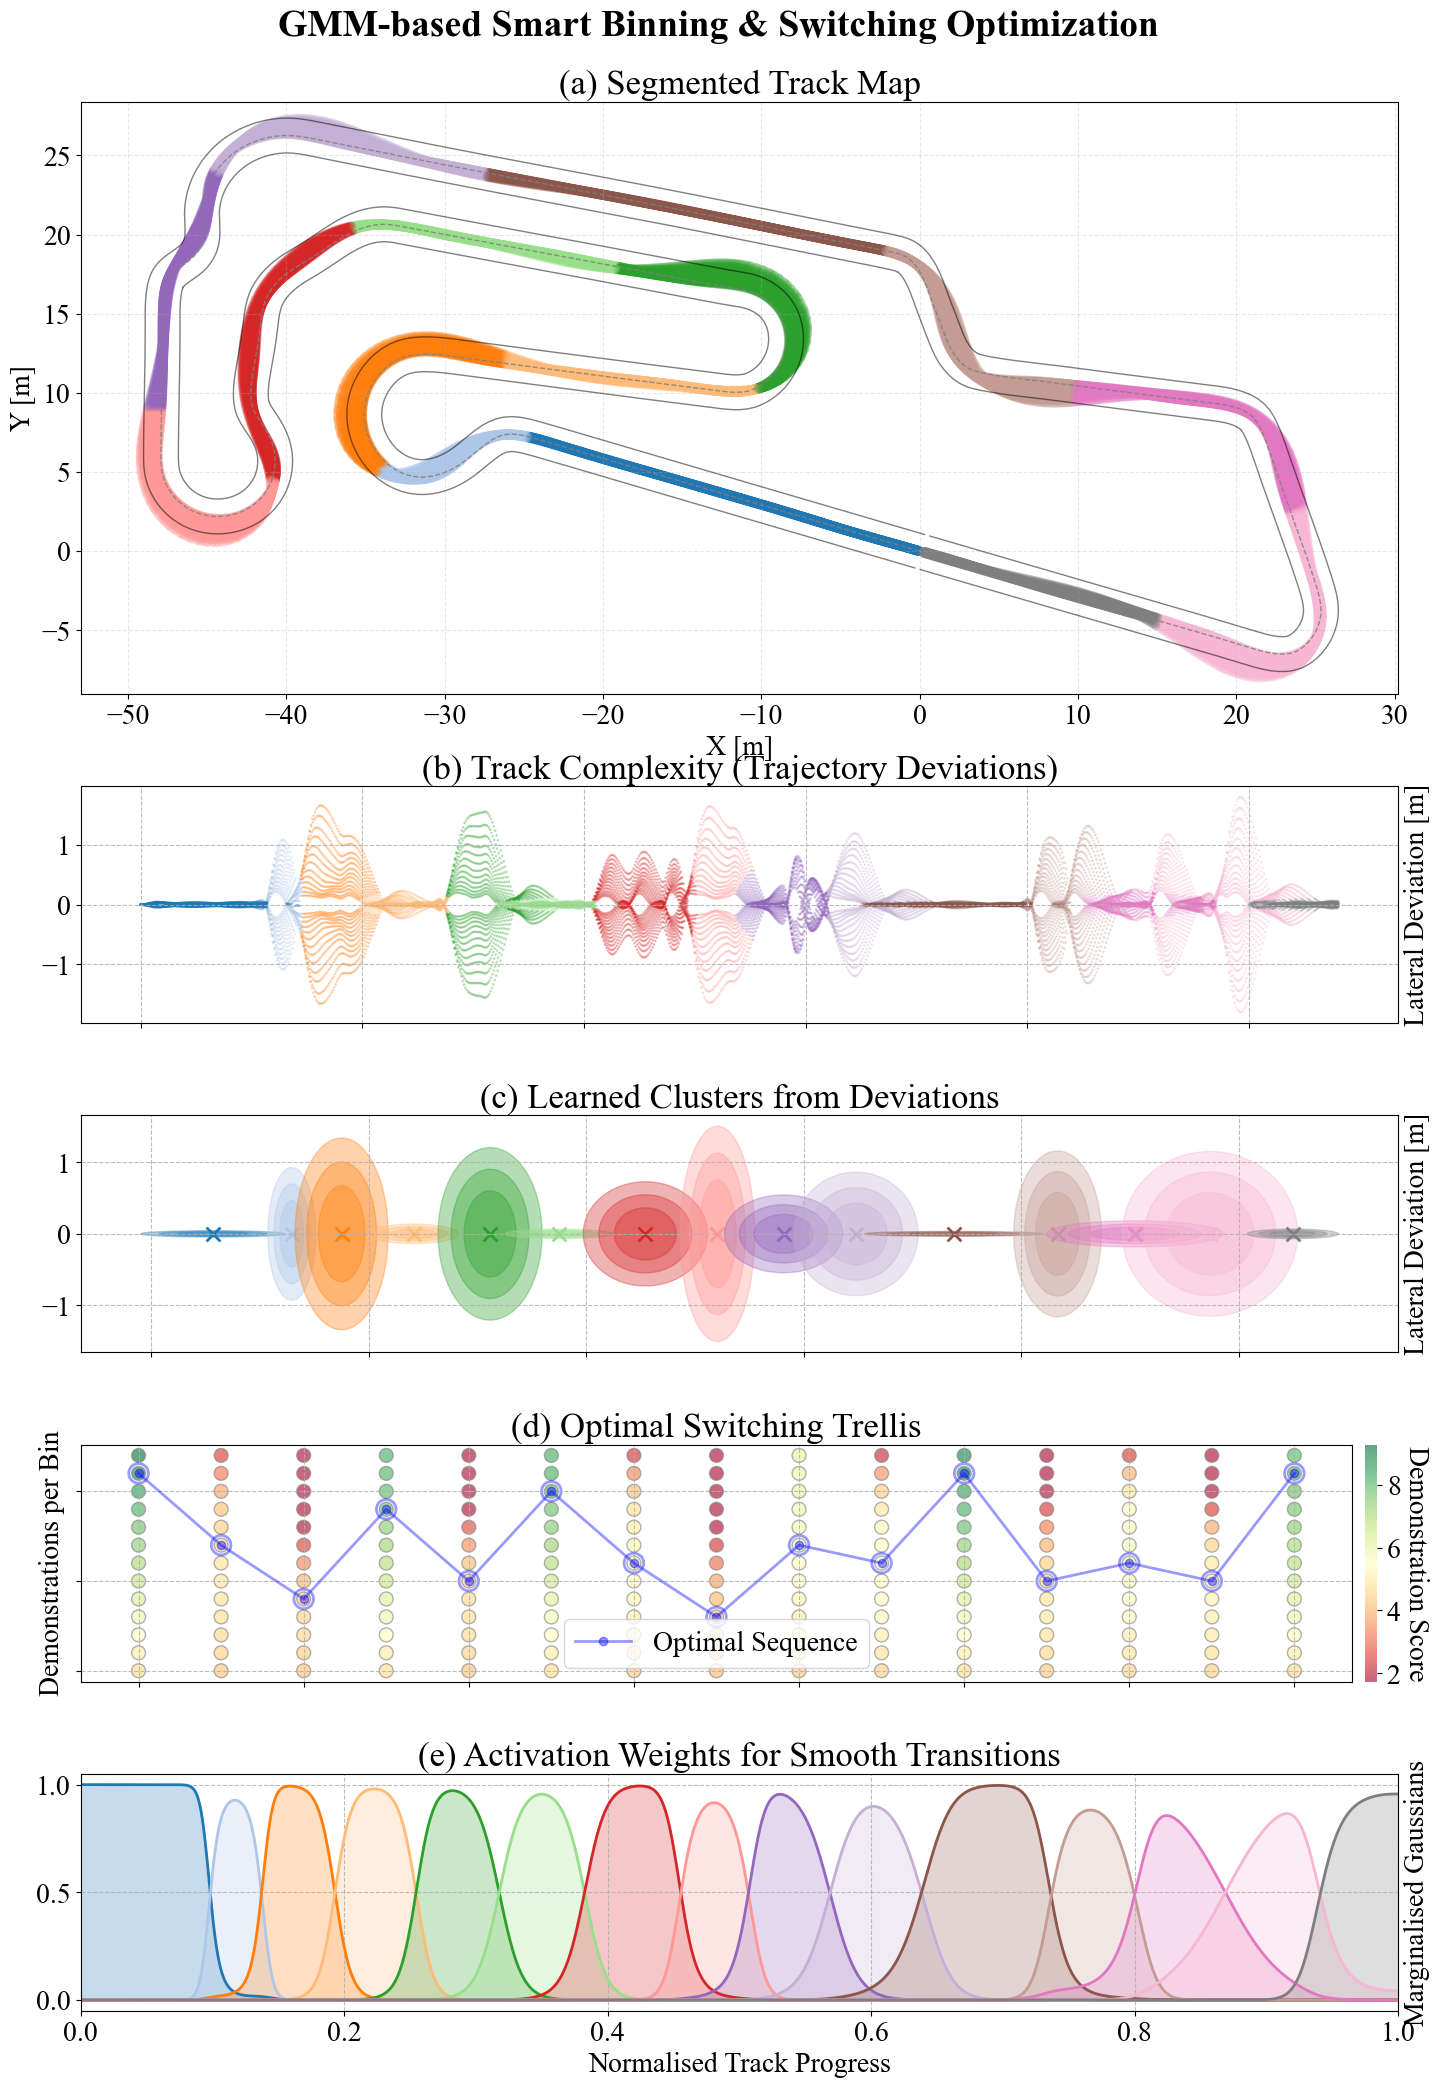

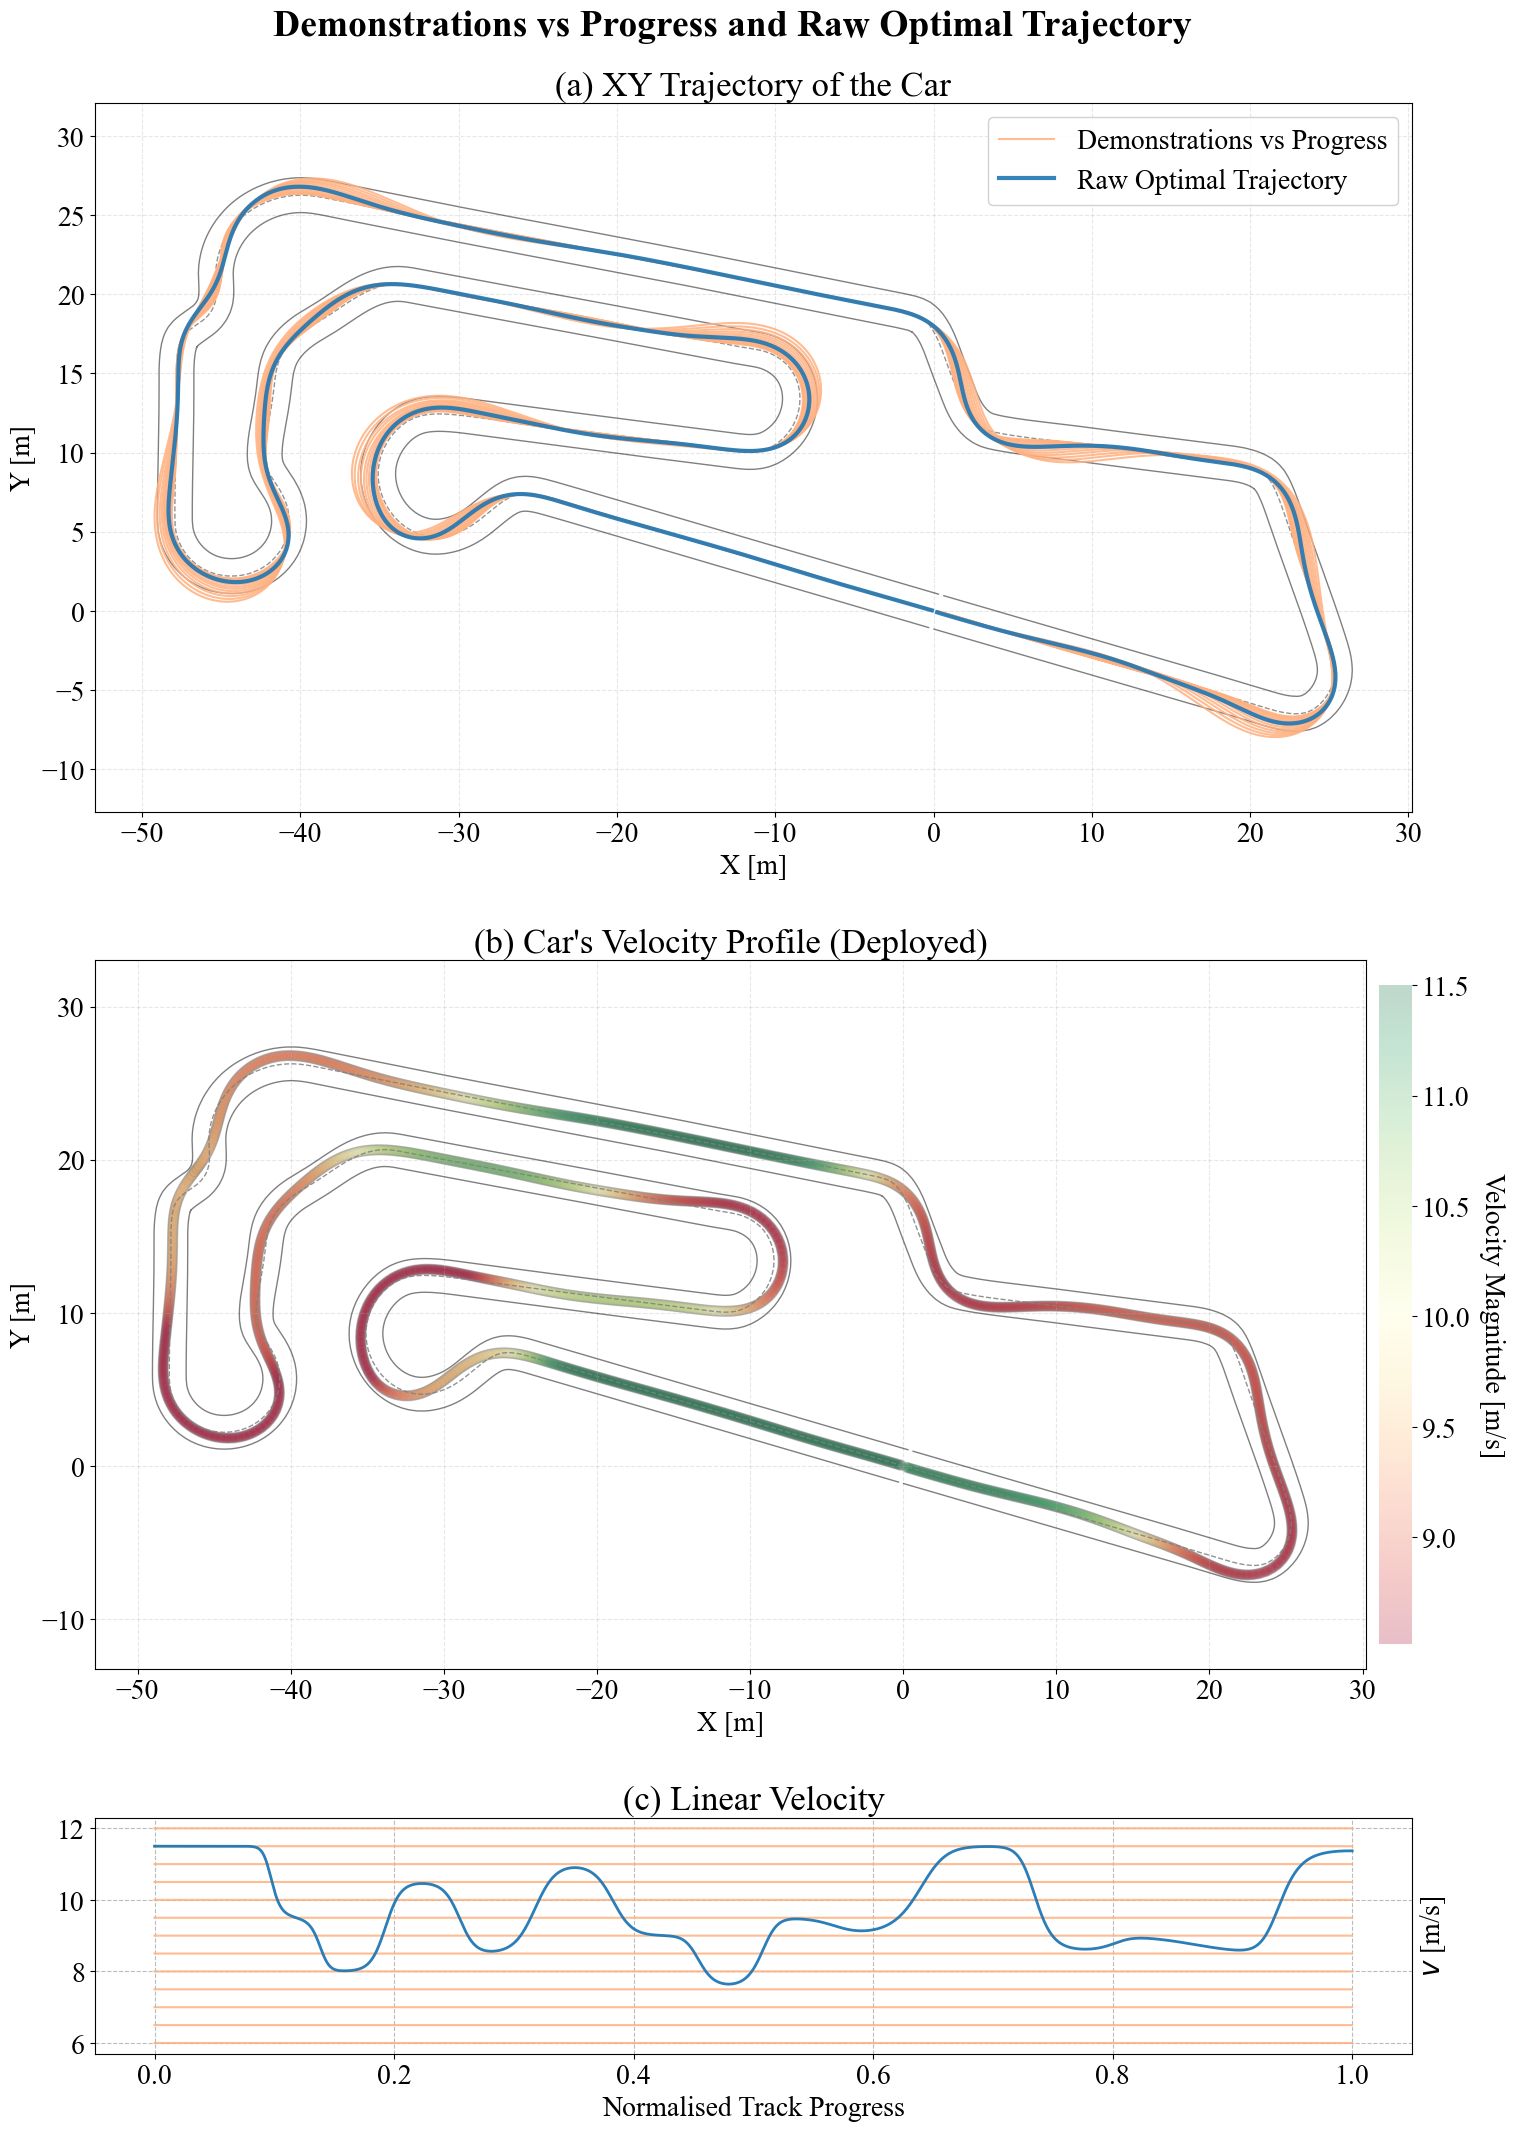

[INFO]: Trajectory Data saved succesfully -> data_dummy\TDList_Learnt_2026-09-11_22-19.pkl


In [15]:
TDOpt = generate_opt_trajectory(
    TDList=TDList_Demo, 
    num_segs=15,                    # Number of adaptive regimes (K)
    safety_width=0.8,               # Bounded distance from centerline (w_safe)
    safety_gain=1.5,                # Reward scaling for precise tracking
    switch_gain=2.0,                # Penalty scaling for high-jerk transitions
    acceleration_max=0.9*C.a_max,   # Physical limit constraint for DP transitions
    track_length=WP.cumulative_dists[-1],
    waypoints_plotter=partial(plot_waypoints, WP.waypoints, WP.waypoints_width),
    filedate=FILEDATE,
)

# Plot the synthesized reference trajectory against the raw experts
plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=[TDOpt], 
    TDList_demo=TDList_Demo,
    TD_demo_name="Demonstrations vs Progress",
    TD_learnt_name="Raw Optimal Trajectory", 
    x_axis_time=False, 
    filedate=FILEDATE,
)

TDOpt['deviations'] = WP.compute_deviations(TDOpt['states'][:, :2])
TRAJ_DATA_PATH = join("data_dummy", f"TDList_Learnt_{FILEDATE}.pkl")
save_traj_data(TDOpt, TRAJ_DATA_PATH)

### 7. Preparing for Execution: $C^2$ Spline and Controller Init
To ensure the synthesized discrete waypoints are kinematically trackable, we fit a continuous $C^2$ spline to the velocity profile. We then initialize the `SwitchingController` (a modified Stanley controller) which uses an anticipative lookahead to track the aggressive velocity schedule safely.

In [16]:
# Fit a smooth B-spline to the blended velocity profile
V_tck = splrep(TDOpt["progress"], TDOpt["states"][:, 3], s=1.)

# Create a new WayPoint object using the optimal synthesized path 
# instead of the track centerline
WP_Learnt = WayPoint(
    waypoints=TDOpt["states"][:, :2],
    waypoint_density=10,
    smoothness_params=np.ones(2),
    plot_waypoints_flag=False,
)

# Initialize the custom high-speed tracking controller
SW = SwitchingController(
    wheelbase_front=C.lf,
    vel_look_ahead_factor=0.25,        # Scales velocity target preview
    velocity_threshold=GCH.vel_thresh, # Prevents division by zero at start
    look_ahead_progress_factor=1.25e-3,# Anticipative spatial preview distance
    k_stanley=0.25*np.mean(TDOpt["states"][:, 3]), # Base gain tuned to average speed
)

In [17]:
# Set the car to the start of the newly synthesized optimal path
CAR_PARAMS["X0"][:2] = WP_Learnt.waypoints[0]
CAR_PARAMS["X0"][3] = splev(0., V_tck)
CAR_PARAMS["X0"][4] = np.arctan2(*((WP_Learnt.waypoints[1]-WP_Learnt.waypoints[0])[::-1]))
C = Car(**CAR_PARAMS)

# %%
TDList_Car = []
X0 = np.copy(CAR_PARAMS["X0"])

# Compute rotation matrix to apply local spatial noise correctly
init_orien_rot = np.array([
    [np.cos(X0[4]), -np.sin(X0[4])],
    [np.sin(X0[4]), np.cos(X0[4])],
])

for i in range(5):
    print(f"\n--------------- TEST {i + 1} --------------\n")

    X0 = np.copy(CAR_PARAMS["X0"])
    
    # Inject spatial noise for tests 2-5 to evaluate recovery stability
    if i > 0:
        forward_offset = np.random.uniform(1e-2, 3e-1)
        lateral_offset = np.random.uniform(-3e-1, 3e-1)
        local_noise = np.array([forward_offset, lateral_offset])
        world_noise = init_orien_rot @ local_noise
        X0[:2] += world_noise

    C.reset(X0=X0, kinematic_flag=False)
    
    # Execute the closed-loop tracking simulation
    TDList_Car.append(simulate_controllers(
        C=C,
        progress_func=WP_Learnt.find_progress_value,
        # Reference targets evaluated from the smoothed optimal splines
        desired_xy_func=lambda progress: np.array([splev(progress+SW.look_ahead_progress, tck) for tck in WP_Learnt.waypoints_tck[:2]]),
        desired_phi_func=lambda progress: np.arctan2(*[splev(progress+SW.look_ahead_progress, tck) for tck in WP_Learnt.waypoints_dot_tck[:2][::-1]]),
        velocity_ctrl_func=lambda progress: splev(progress+SW.look_ahead_progress*SW.vel_look_ahead_factor, V_tck),
        steering_ctrl_fun=SW.stanley_ctrl_modified,
        completion_thresh=0.25/WP_Learnt.cumulative_dists[-1],
        simulation_duration=75.,
    ))
    
    # Log deviation to ensure recovery doesn't violate safety bounds
    TDList_Car[-1]["deviations"] = WP.compute_deviations(TDList_Car[-1]["states"][:, :2])
    print_details([TDList_Car[-1]])

print("\n")


--------------- TEST 1 --------------

[INFO]: Lap Time Stats -> Min = 27.06 s
[INFO]: Lap Time Stats -> Mean = 27.06 s
[INFO]: Lap Time Stats -> Max = 27.06 s
[INFO]: Speed Stats -> Min = 7.6368 m/s
[INFO]: Speed Stats -> Mean = 9.5769 m/s
[INFO]: Speed Stats -> Max = 11.5106 m/s
[INFO]: Deviation Stats -> Min = 0.0 m
[INFO]: Deviation Stats -> Mean = 0.1995 m
[INFO]: Deviation Stats -> Max = 0.7679 m

--------------- TEST 2 --------------

[INFO]: Lap Time Stats -> Min = 27.05 s
[INFO]: Lap Time Stats -> Mean = 27.05 s
[INFO]: Lap Time Stats -> Max = 27.05 s
[INFO]: Speed Stats -> Min = 7.6368 m/s
[INFO]: Speed Stats -> Mean = 9.5762 m/s
[INFO]: Speed Stats -> Max = 11.5106 m/s
[INFO]: Deviation Stats -> Min = 0.0001 m
[INFO]: Deviation Stats -> Mean = 0.2045 m
[INFO]: Deviation Stats -> Max = 0.7665 m

--------------- TEST 3 --------------

[INFO]: Lap Time Stats -> Min = 27.05 s
[INFO]: Lap Time Stats -> Mean = 27.05 s
[INFO]: Lap Time Stats -> Max = 27.05 s
[INFO]: Speed Stats ->

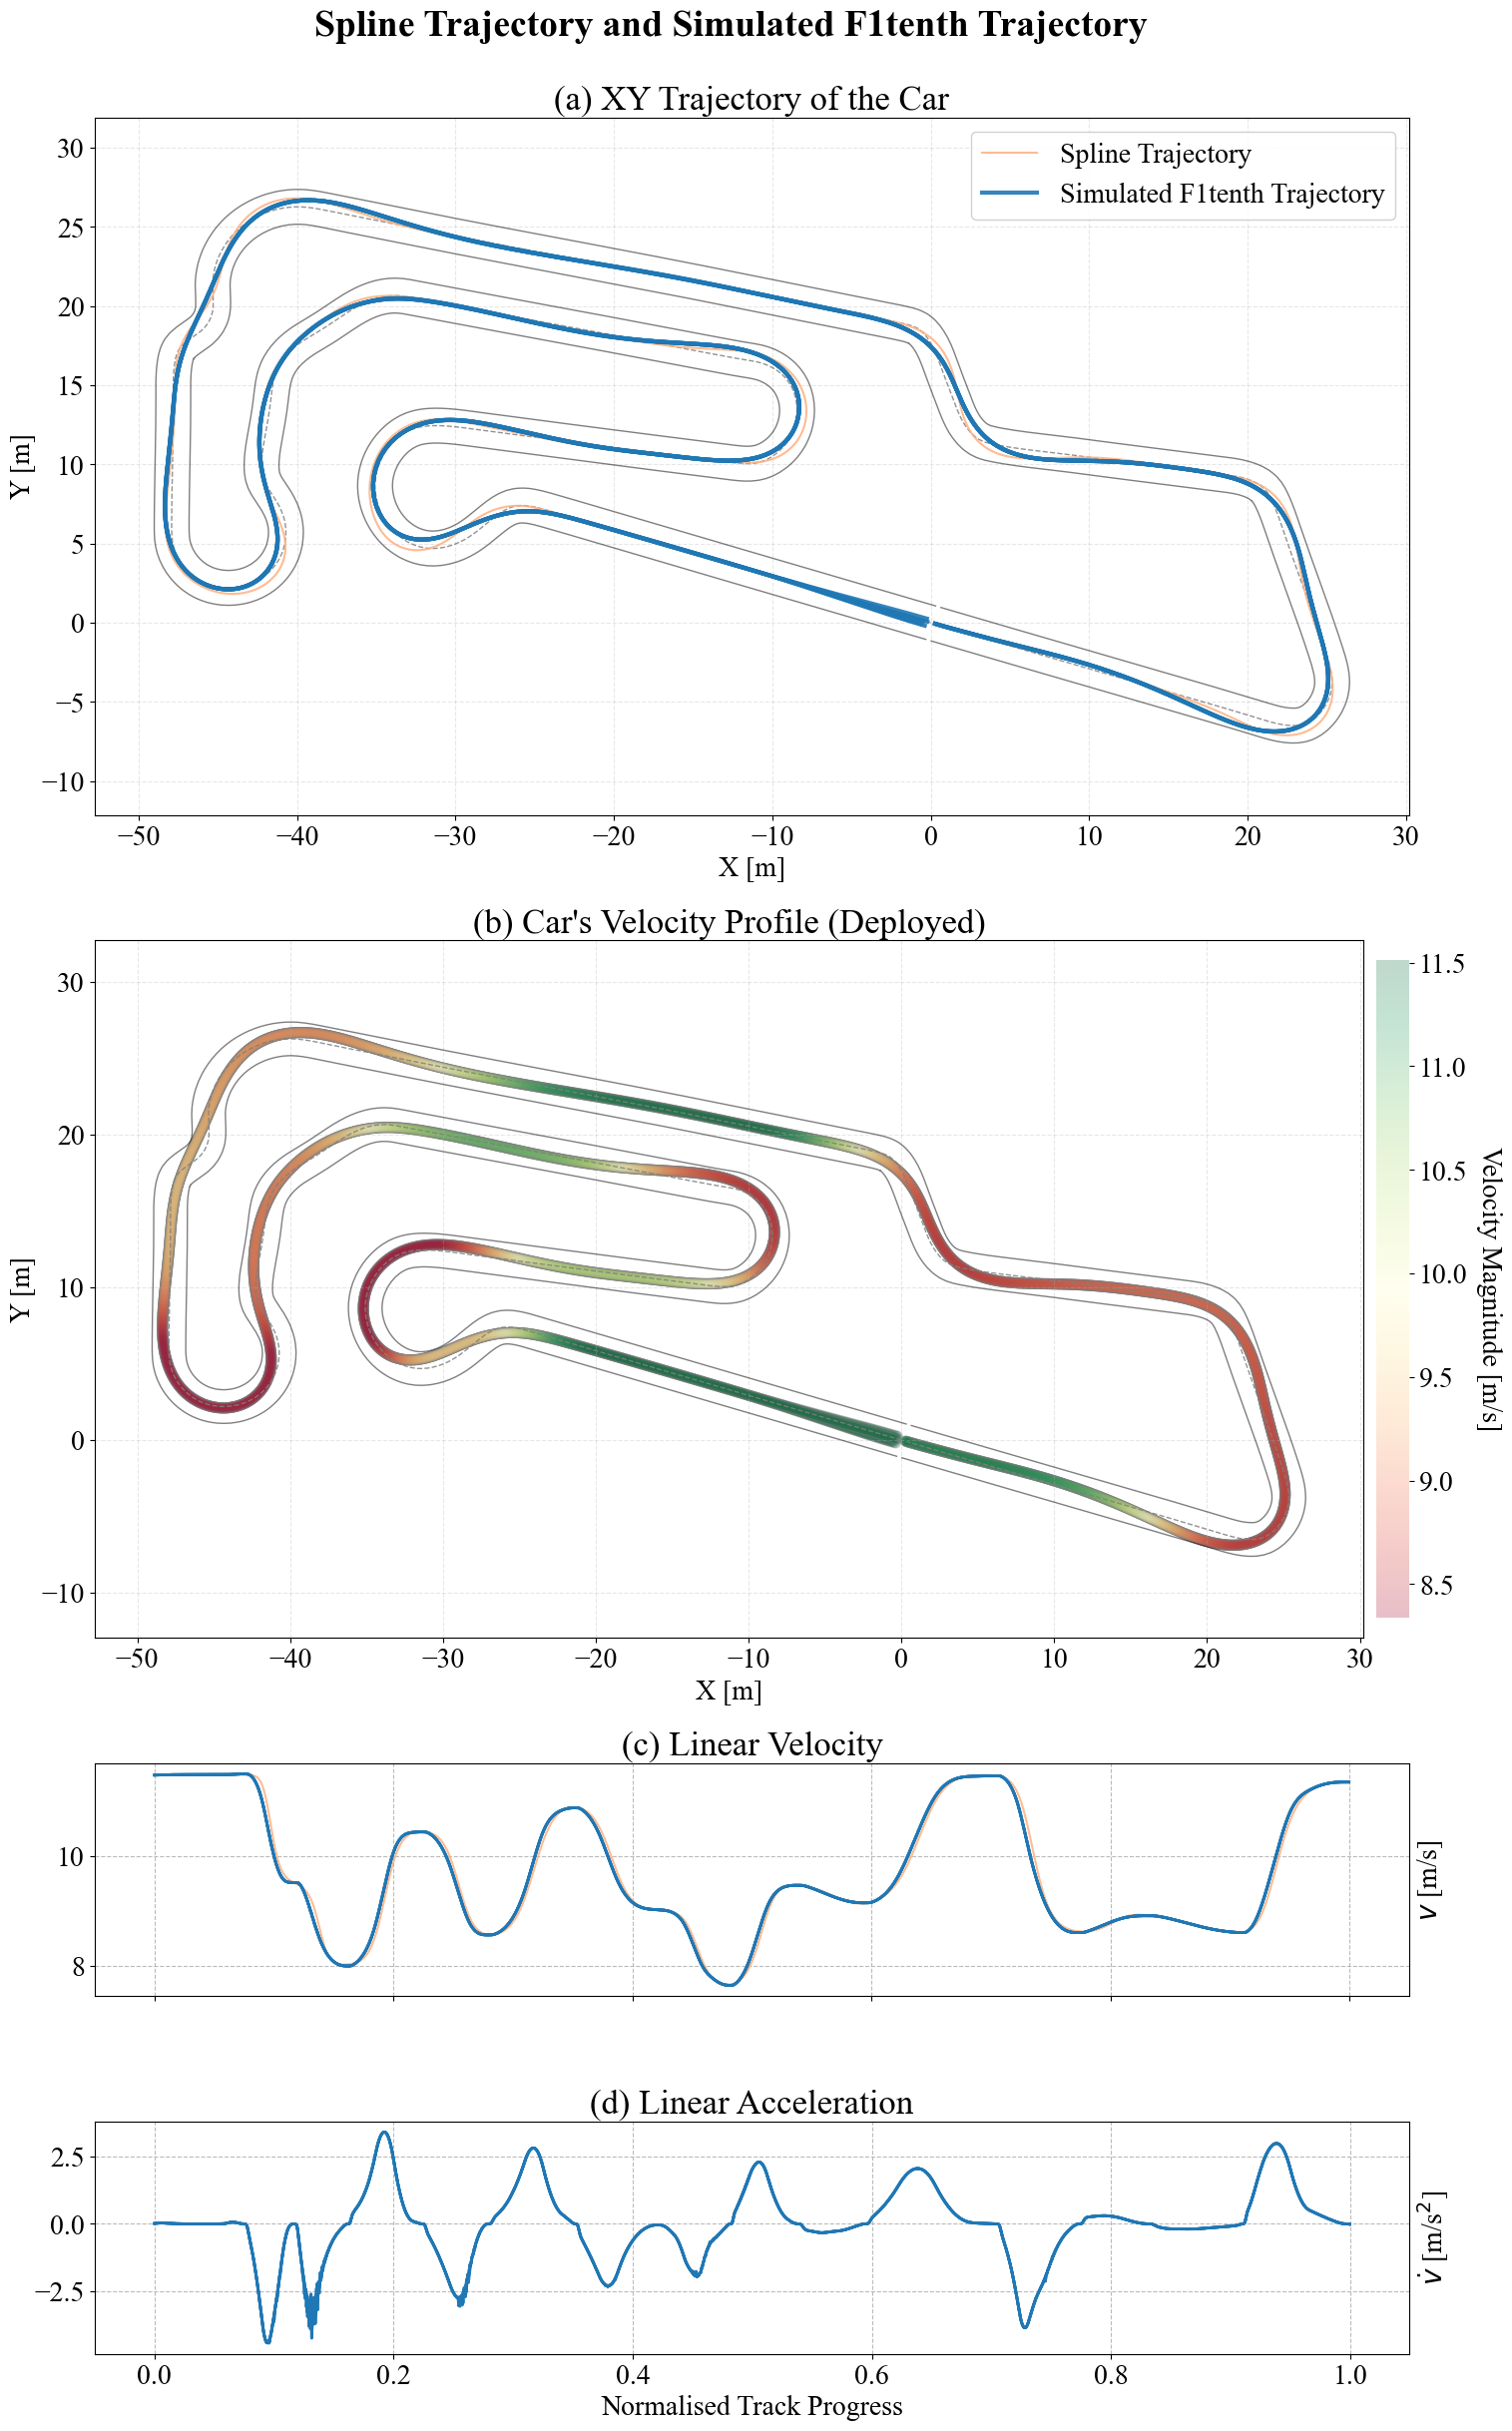

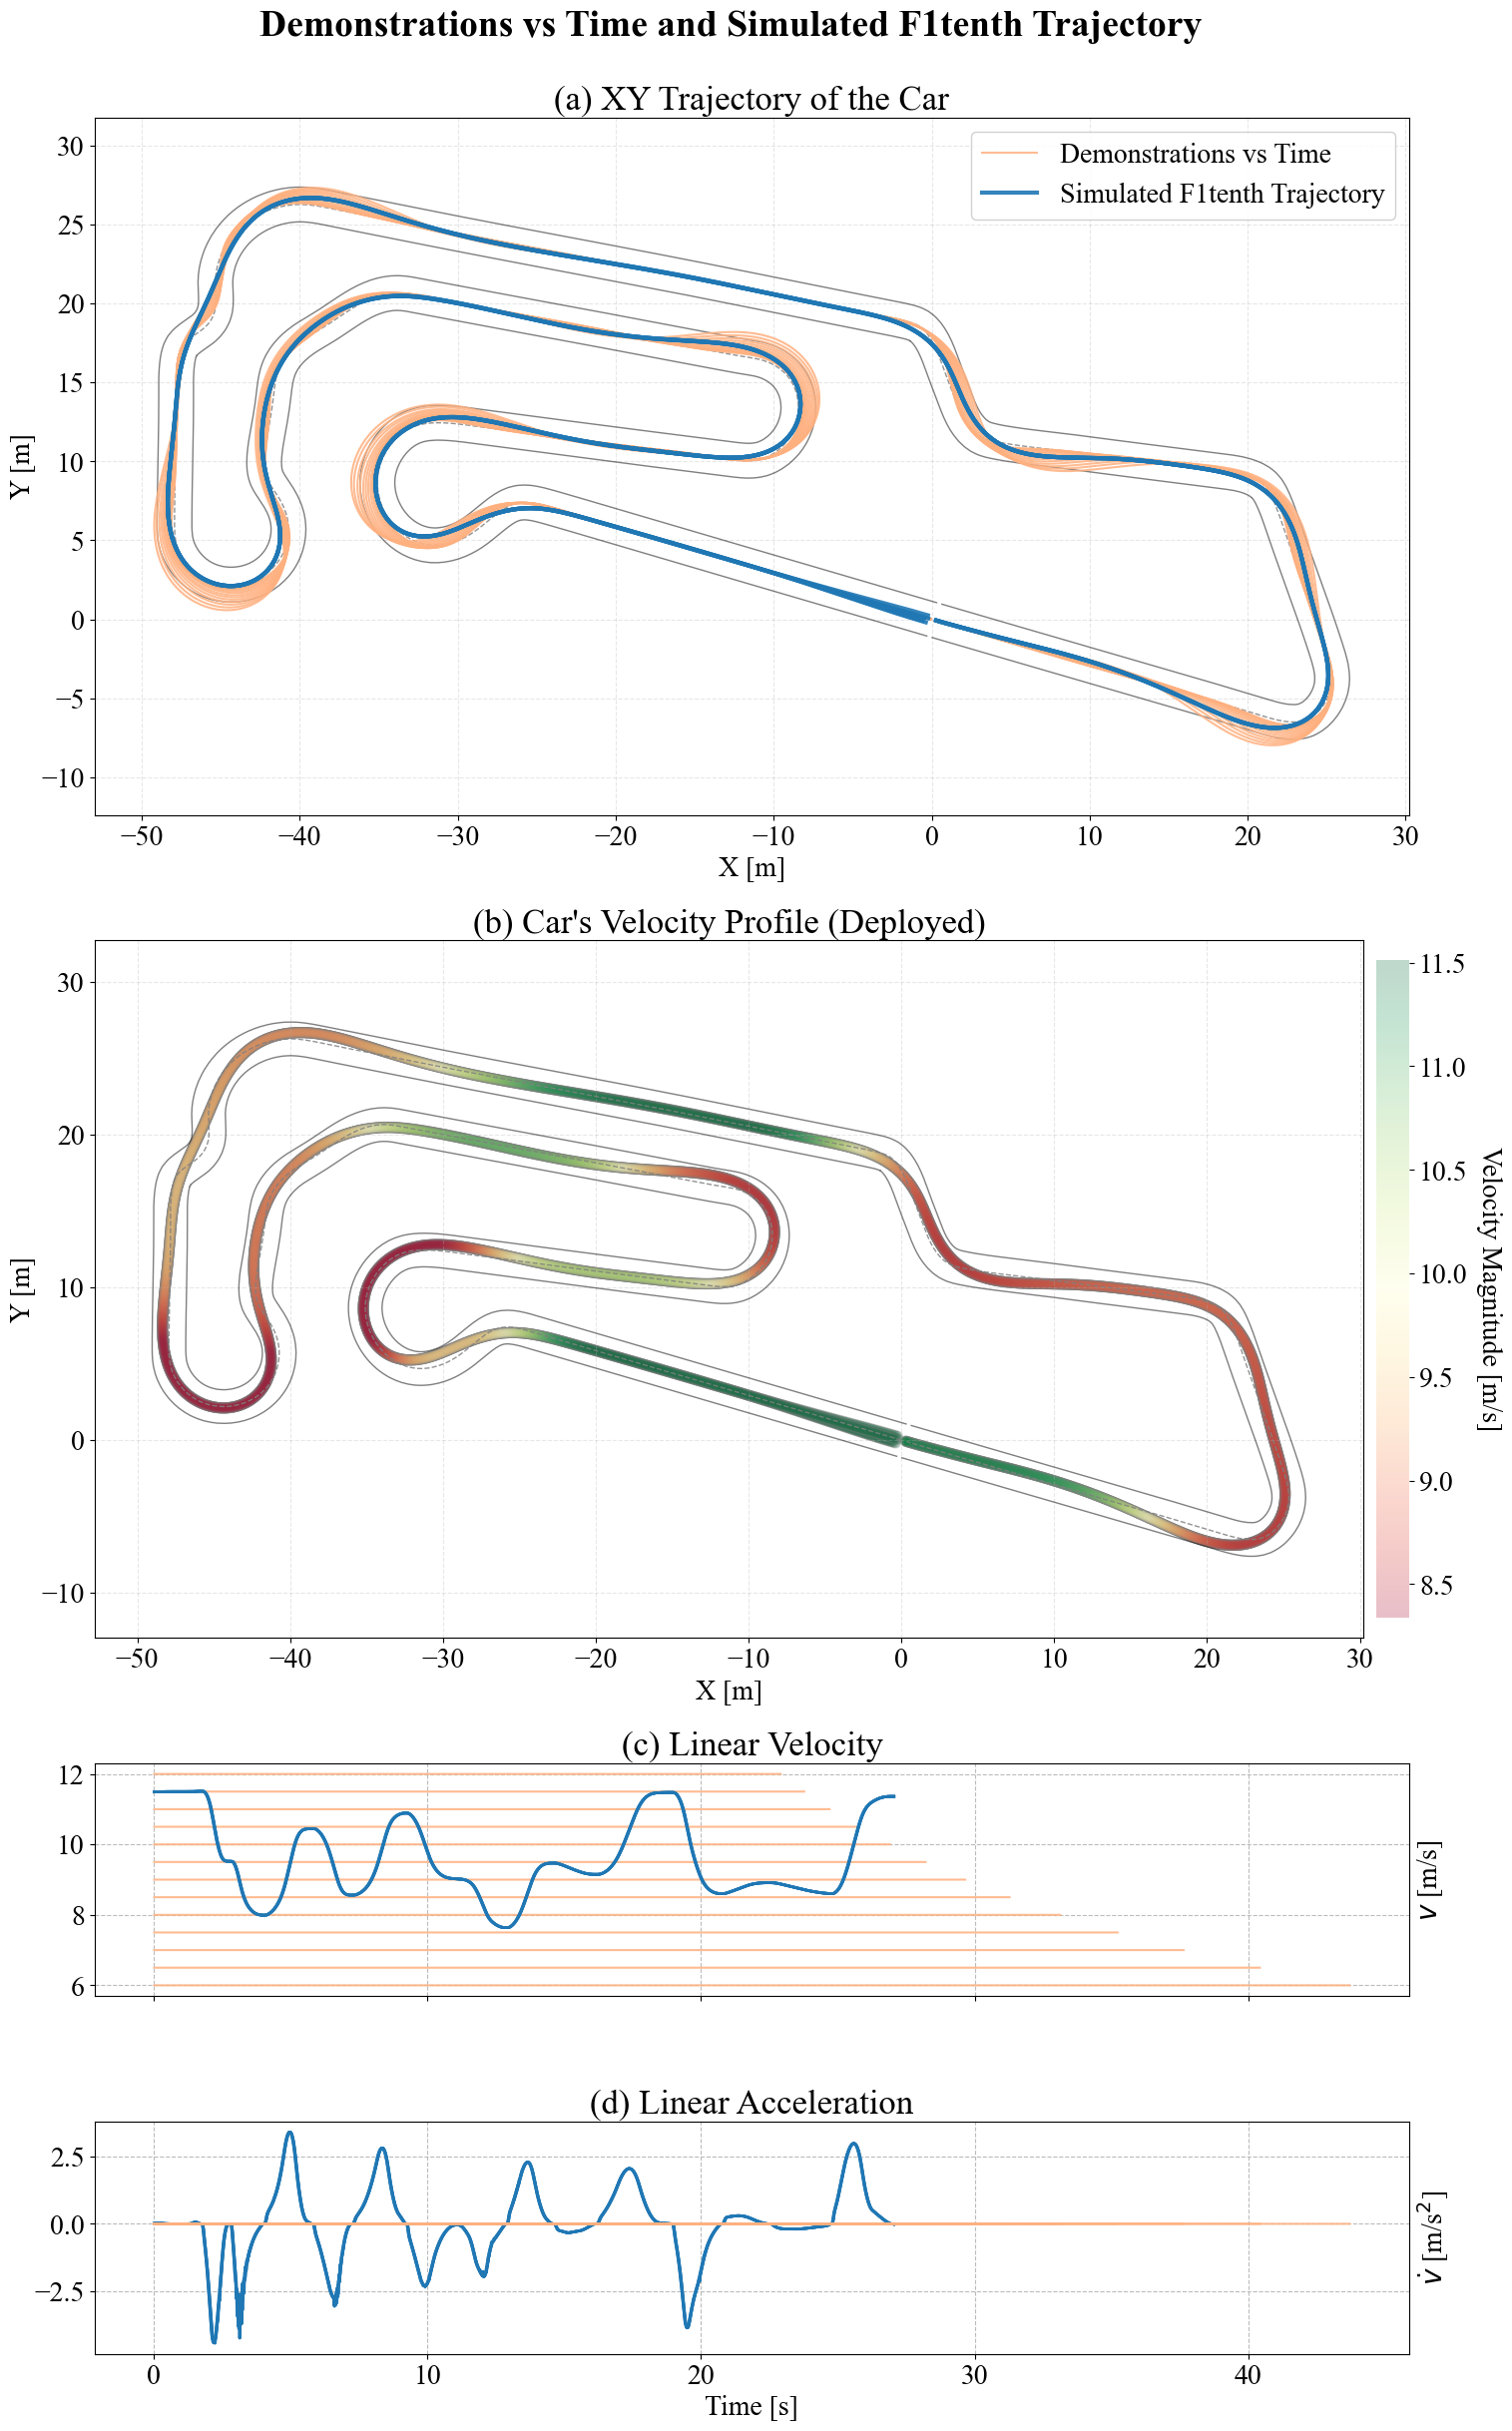

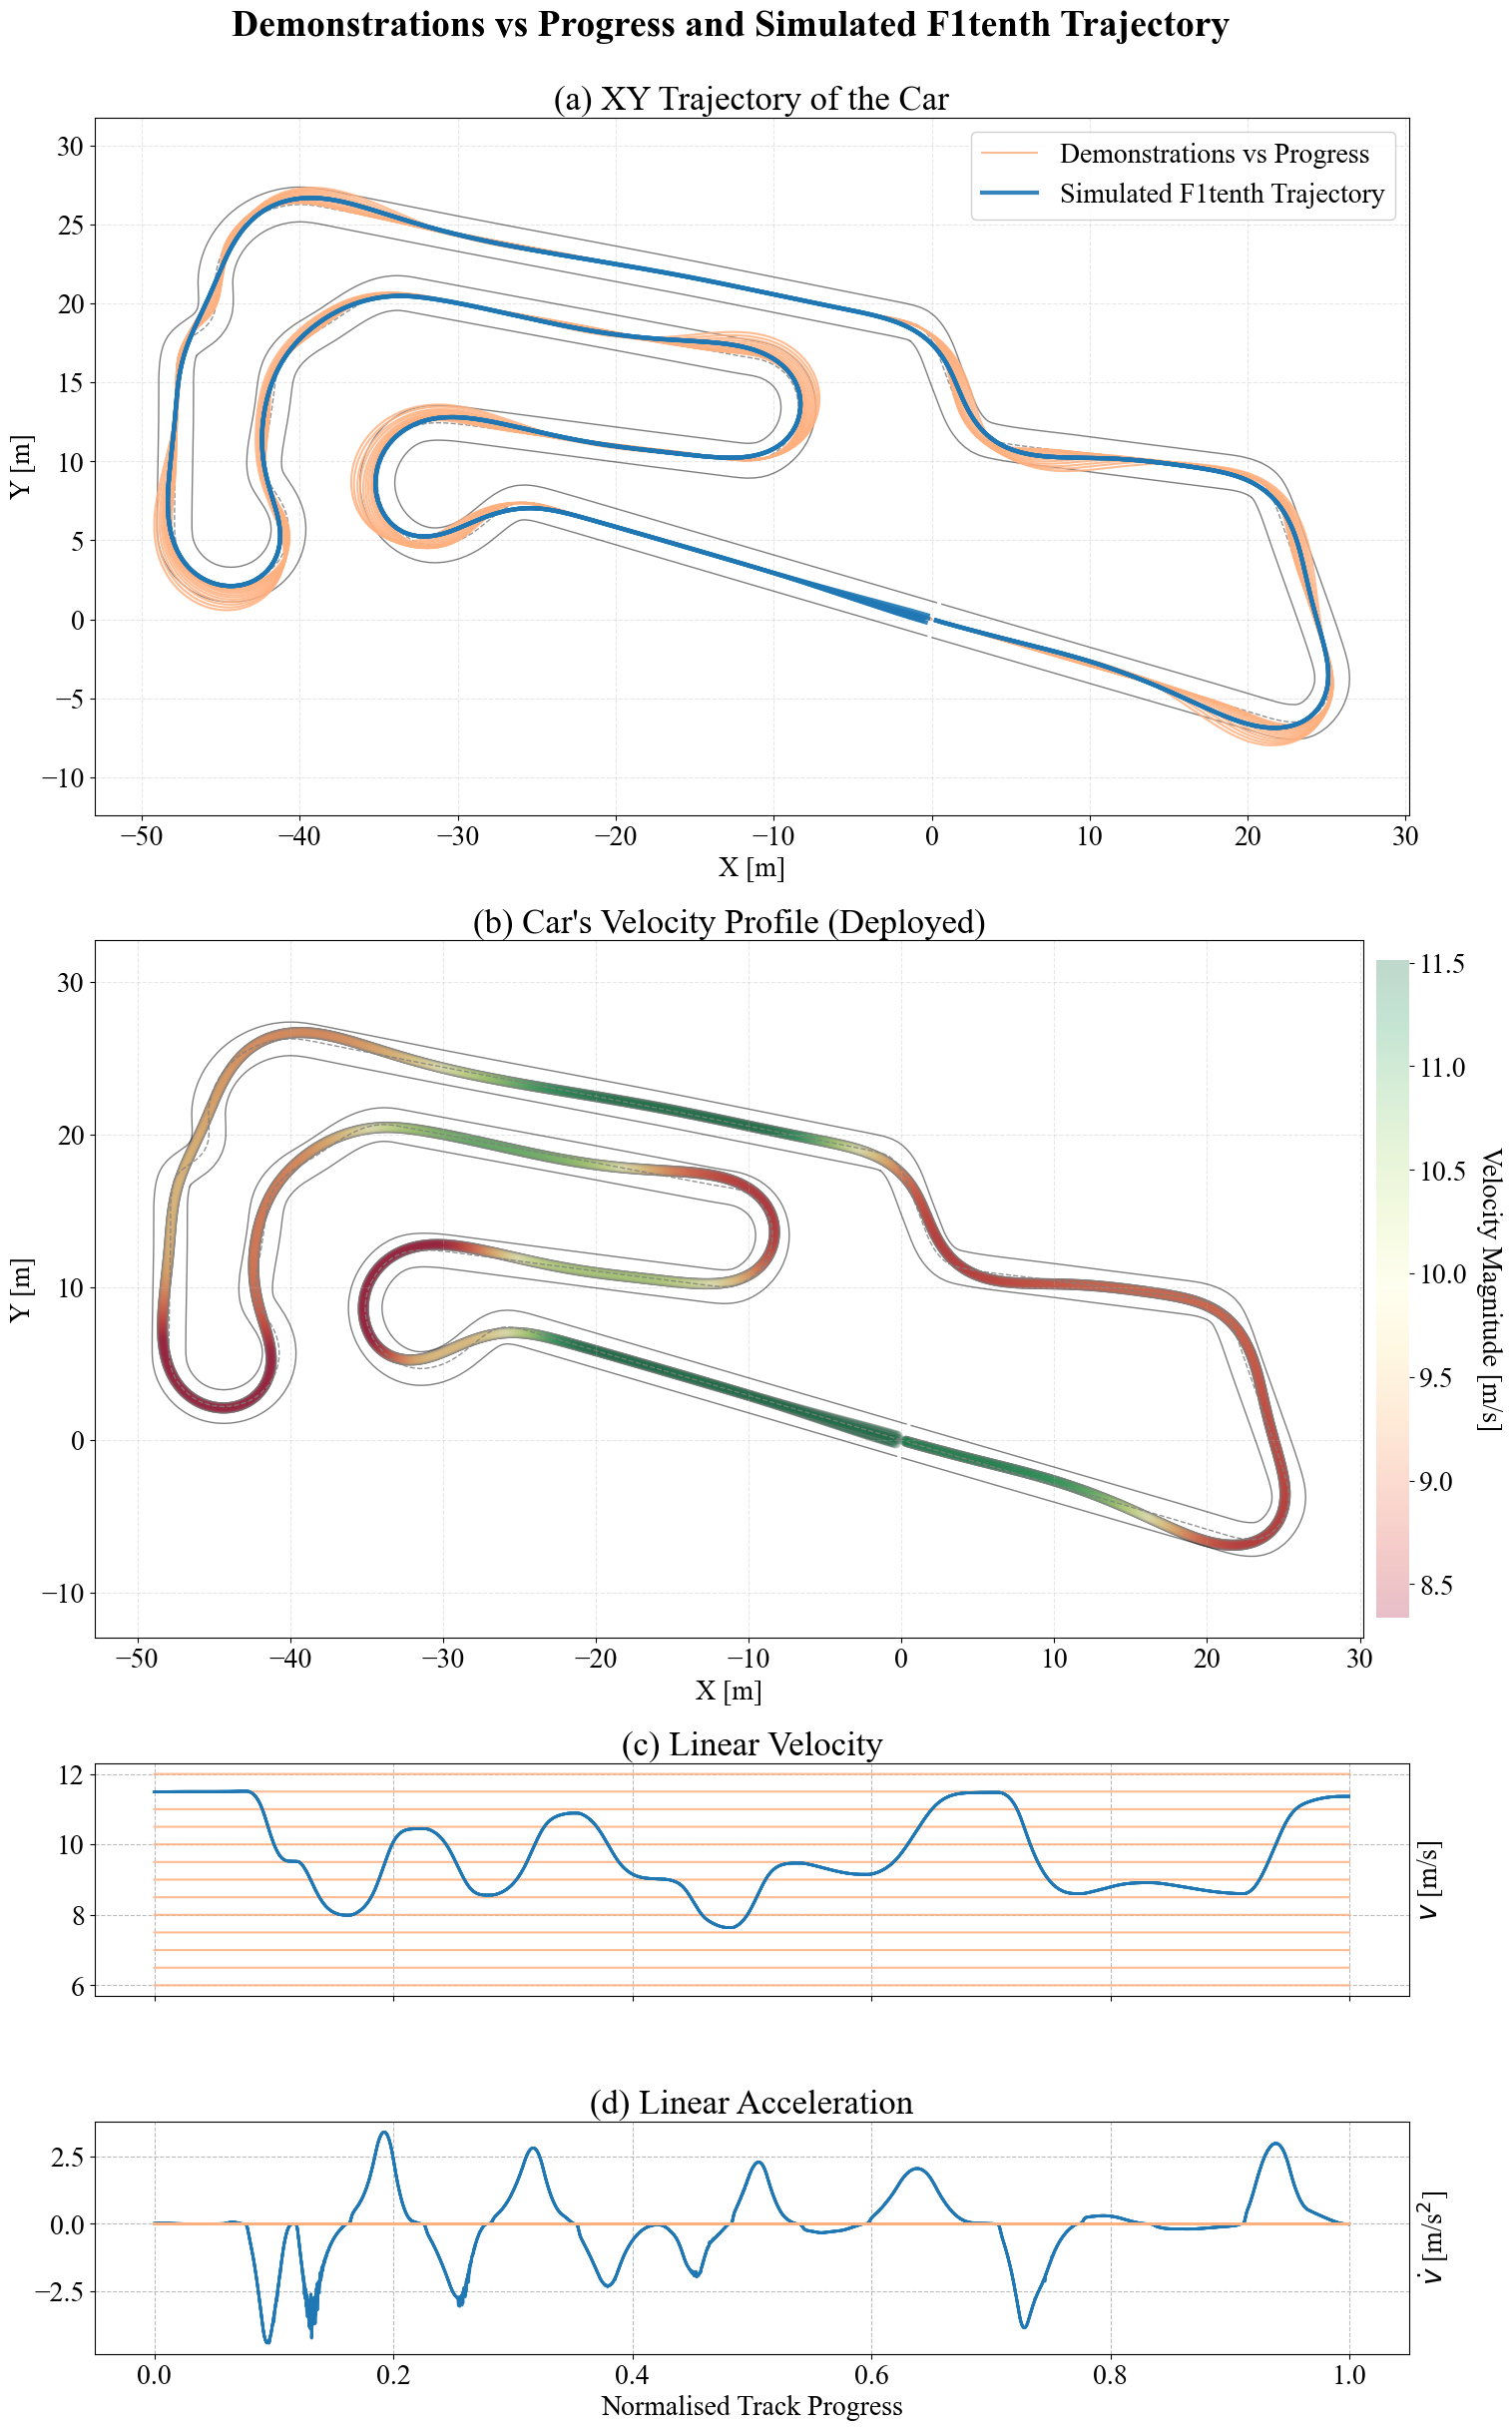

In [18]:
plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=TDList_Car, 
    TDList_demo=[TDOpt], 
    plot_state_dot_indices = [3],
    TD_demo_name="Spline Trajectory",
    TD_learnt_name="Simulated F1tenth Trajectory", 
    x_axis_time=False, 
)

# %%
plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=TDList_Car, 
    TDList_demo=TDList_Demo, 
    plot_state_dot_indices = [3],
    TD_demo_name="Demonstrations vs Time",
    TD_learnt_name="Simulated F1tenth Trajectory", 
    filedate=FILEDATE
)

plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=TDList_Car, 
    TDList_demo=TDList_Demo, 
    plot_state_dot_indices = [3],
    TD_demo_name="Demonstrations vs Progress",
    TD_learnt_name="Simulated F1tenth Trajectory", 
    x_axis_time=False, 
    filedate=FILEDATE
)